<a href="https://colab.research.google.com/github/habibarezq/ML-Assignments-25/blob/main/Assingment-4/notebooks/exp1%263.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Experiment 1: K-Means on Original Data

Imports

In [113]:
!pwd

/content/ML-Assignments-25/Assingment-4/notebooks


In [114]:
import os, sys, importlib
sys.path.append(os.path.abspath('../src'))
from kmeans import NumpyKMeans

In [115]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score as sk_silhouette, confusion_matrix
import internal_metrics, external_metrics
from internal_metrics import silhouette_score, davies_bouldin_index, within_cluster_sum_squares, calinski_harabasz_index
from external_metrics import adjusted_rand_index, normalized_mutual_information, purity

Loading the dataset

In [116]:
dataset = load_breast_cancer()
X=dataset.data
y=dataset.target
print("Dataset Information:")
print(f"Number of samples: {X.shape[0]}")
print(f"Number of features: {X.shape[1]}")
print(f"Feature names: {dataset.feature_names}")
print(f"\nClass distribution:")
print(f"Class 0 (malignant): {np.sum(y == 0)}")
print(f"Class 1 (benign): {np.sum(y == 1)}")


Dataset Information:
Number of samples: 569
Number of features: 30
Feature names: ['mean radius' 'mean texture' 'mean perimeter' 'mean area'
 'mean smoothness' 'mean compactness' 'mean concavity'
 'mean concave points' 'mean symmetry' 'mean fractal dimension'
 'radius error' 'texture error' 'perimeter error' 'area error'
 'smoothness error' 'compactness error' 'concavity error'
 'concave points error' 'symmetry error' 'fractal dimension error'
 'worst radius' 'worst texture' 'worst perimeter' 'worst area'
 'worst smoothness' 'worst compactness' 'worst concavity'
 'worst concave points' 'worst symmetry' 'worst fractal dimension']

Class distribution:
Class 0 (malignant): 212
Class 1 (benign): 357


In [117]:
print(f"Missing values: {np.isnan(X).sum()}")  # Should be 0

Missing values: 0


In [118]:
def standardize(X):
    mean = np.mean(X, axis=0)
    std = np.std(X, axis=0)

    # Avoid division by zero for constant features
    std[std == 0] = 1

    X_scaled = (X - mean) / std

    return X_scaled, mean, std

In [119]:
# Standardize
X_scaled, mean, std = standardize(X)

print(f"Original - Mean: {X.mean():.2f}, Std: {X.std():.2f}")
print(f"Scaled   - Mean: {X_scaled.mean():.2f}, Std: {X_scaled.std():.2f}")

Original - Mean: 61.89, Std: 228.30
Scaled   - Mean: -0.00, Std: 1.00


# Starting Experiment 1: K-Means on Original Data

## Finding Optimal K Using 3 Methods

In [120]:
# HYPERPARAMETERS (document all as required)
k_range = range(2, 21)
n_runs = 3      # number of runs for convergence averaging
max_iter = 300  # max 300 iterations before forced stop
tol = 1e-4      # stop if inertia change < 0.0001
random_seed = 42
np.random.seed(random_seed)

In [121]:
## 1. ELBOW METHOD
inertias_pp = [] # list to store inertias of different k values
for k in k_range:
    km = NumpyKMeans(n_clusters=k, init='k-means++', max_iter=max_iter, tol=tol, random_state=random_seed) # create k-means with k clusters
    km.fit(X_scaled)
    inertias_pp.append(km.inertia_)

In [122]:
## 2. SILHOUETTE ANALYSIS (implementation in internal_metrics.py)
sil_scores = []  # from-scratch silhouette scores
sil_scores_sk = []  # scikit-learn version (for validation only)
for k in k_range:  # k=2 to 20
    km = NumpyKMeans(n_clusters=k, init='k-means++', random_state=random_seed)
    km.fit(X_scaled)
    sil = silhouette_score(X_scaled, km.labels_)
    sil_scores.append(sil)  # Save avg silhouette for this k
    sil_scores_sk.append(sk_silhouette(X_scaled, km.labels_))
k_sil = k_range[np.argmax(sil_scores)]  # Optimal k = highest silhouette


In [123]:
## 3. GAP STATISTIC:  Compares real data clustering to random noise
def compute_gap_statistic(X, k_range, B=10):
    gaps = np.zeros(len(k_range))
    inertias_ref = np.zeros((B, len(k_range))) # 10 x range of k (0-19)

    for b in range(B):
        # Generate reference data (uniform in PCA bounding box)
        pca_range = np.max(X, axis=0) - np.min(X, axis=0)
        ref_data = np.random.rand(X.shape[0], X.shape[1]) * pca_range + np.min(X, axis=0) # create 10 random datasets (B=10)

        for i, k in enumerate(k_range):
            km_ref = NumpyKMeans(n_clusters=k, init='random', random_state=b*10+i) # cluster random data for k=2..20 → get inertias_ref
            km_ref.fit(ref_data)
            inertias_ref[b, i] = np.log(km_ref.inertia_)

    for i, k in enumerate(k_range):
        km = NumpyKMeans(n_clusters=k, init='k-means++', random_state=random_seed)
        km.fit(X)
        gaps[i] = np.mean(inertias_ref[:, i]) - np.log(km.inertia_) # compute gaps -> big positive gap = real clusters beat random noise

    return k_range[np.argmax(gaps)], gaps

k_gap, gaps = compute_gap_statistic(X_scaled, k_range)
print(f"Gap optimal k: {k_gap}")


Gap optimal k: 19


In [124]:
print(f"Optimal k - Elbow: ~{np.argmin(np.diff(inertias_pp))+2}, Silhouette: {k_sil}, Gap: {k_gap}")

Optimal k - Elbow: ~2, Silhouette: 2, Gap: 19


## Comparing K-means++ vs Random

In [125]:
## 4. CONVERGENCE SPEED: K-Means++ vs Random
conv_pp, conv_rand = [], []  # lists

for k in [k_sil, k_gap]: # test both optimal k values (silhouette + gap)

    # K-Means++ (3 runs average)
    iters_pp = []
    for _ in range(n_runs):
        km_pp = NumpyKMeans(n_clusters=k, init='k-means++')
        iters_pp.append(km_pp.fit(X_scaled).n_iter_) # number of iterations to converge for 3 runs
    conv_pp.append(np.mean(iters_pp)) # avg of these 3 runs for each k

    # Random initialization (3 runs average)
    iters_rand = []
    for _ in range(n_runs):
        km_rand = NumpyKMeans(n_clusters=k, init='random', random_state=None)
        iters_rand.append(km_rand.fit(X_scaled).n_iter_)
    conv_rand.append(np.mean(iters_rand))

print(f"K-Means++: {np.mean(conv_pp):.1f}±{np.std(conv_pp):.1f} iterations")
print(f"Random:    {np.mean(conv_rand):.1f}±{np.std(conv_rand):.1f} iterations")


K-Means++: 13.5±4.5 iterations
Random:    12.3±3.7 iterations


## Final Metrics Using Optimal k

In [126]:
optimal_k = k_sil  # use silhouette optimal
km_final = NumpyKMeans(n_clusters=optimal_k, init='k-means++', random_state=random_seed)
km_final.fit(X_scaled)
labels_final = km_final.labels_

# internal metrics
sil_custom = silhouette_score(X_scaled, labels_final)
sil_sklearn = sk_silhouette(X_scaled, labels_final)
db = davies_bouldin_index(X_scaled, labels_final)
ch = calinski_harabasz_index(X_scaled, labels_final)
wcss = within_cluster_sum_squares(X_scaled, labels_final)

# external metrics
ari = adjusted_rand_index(y, labels_final)
nmi = normalized_mutual_information(y, labels_final)
pur = purity(y, labels_final)
cm = confusion_matrix(y, labels_final)

# display all metrics
print("📈 INTERNAL METRICS:")
print(f"Silhouette (custom): {sil_custom:.4f}")
print(f"Silhouette (sklearn): {sil_sklearn:.4f}")
print(f"Davies-Bouldin: {db:.4f}")
print(f"Calinski–Harabasz: {ch:.4f}")
print(f"WCSS: {wcss:.4f}")
print(f"Inertia: {km_final.inertia_:.4f}")

print("\n📈 EXTERNAL METRICS:")
print(f"ARI: {ari:.4f}")
print(f"NMI: {nmi:.4f}")
print(f"Purity: {pur:.4f}")
print("\nConfusion Matrix (rows=true classes, cols=clusters):")
print(cm)

📈 INTERNAL METRICS:
Silhouette (custom): 0.3447
Silhouette (sklearn): 0.3447
Davies-Bouldin: 0.6546
Calinski–Harabasz: 267.6804
WCSS: 11595.6833
Inertia: 11595.6833

📈 EXTERNAL METRICS:
ARI: 0.6765
NMI: 0.5621
Purity: 0.9121

Confusion Matrix (rows=true classes, cols=clusters):
[[ 37 175]
 [344  13]]


# Plots

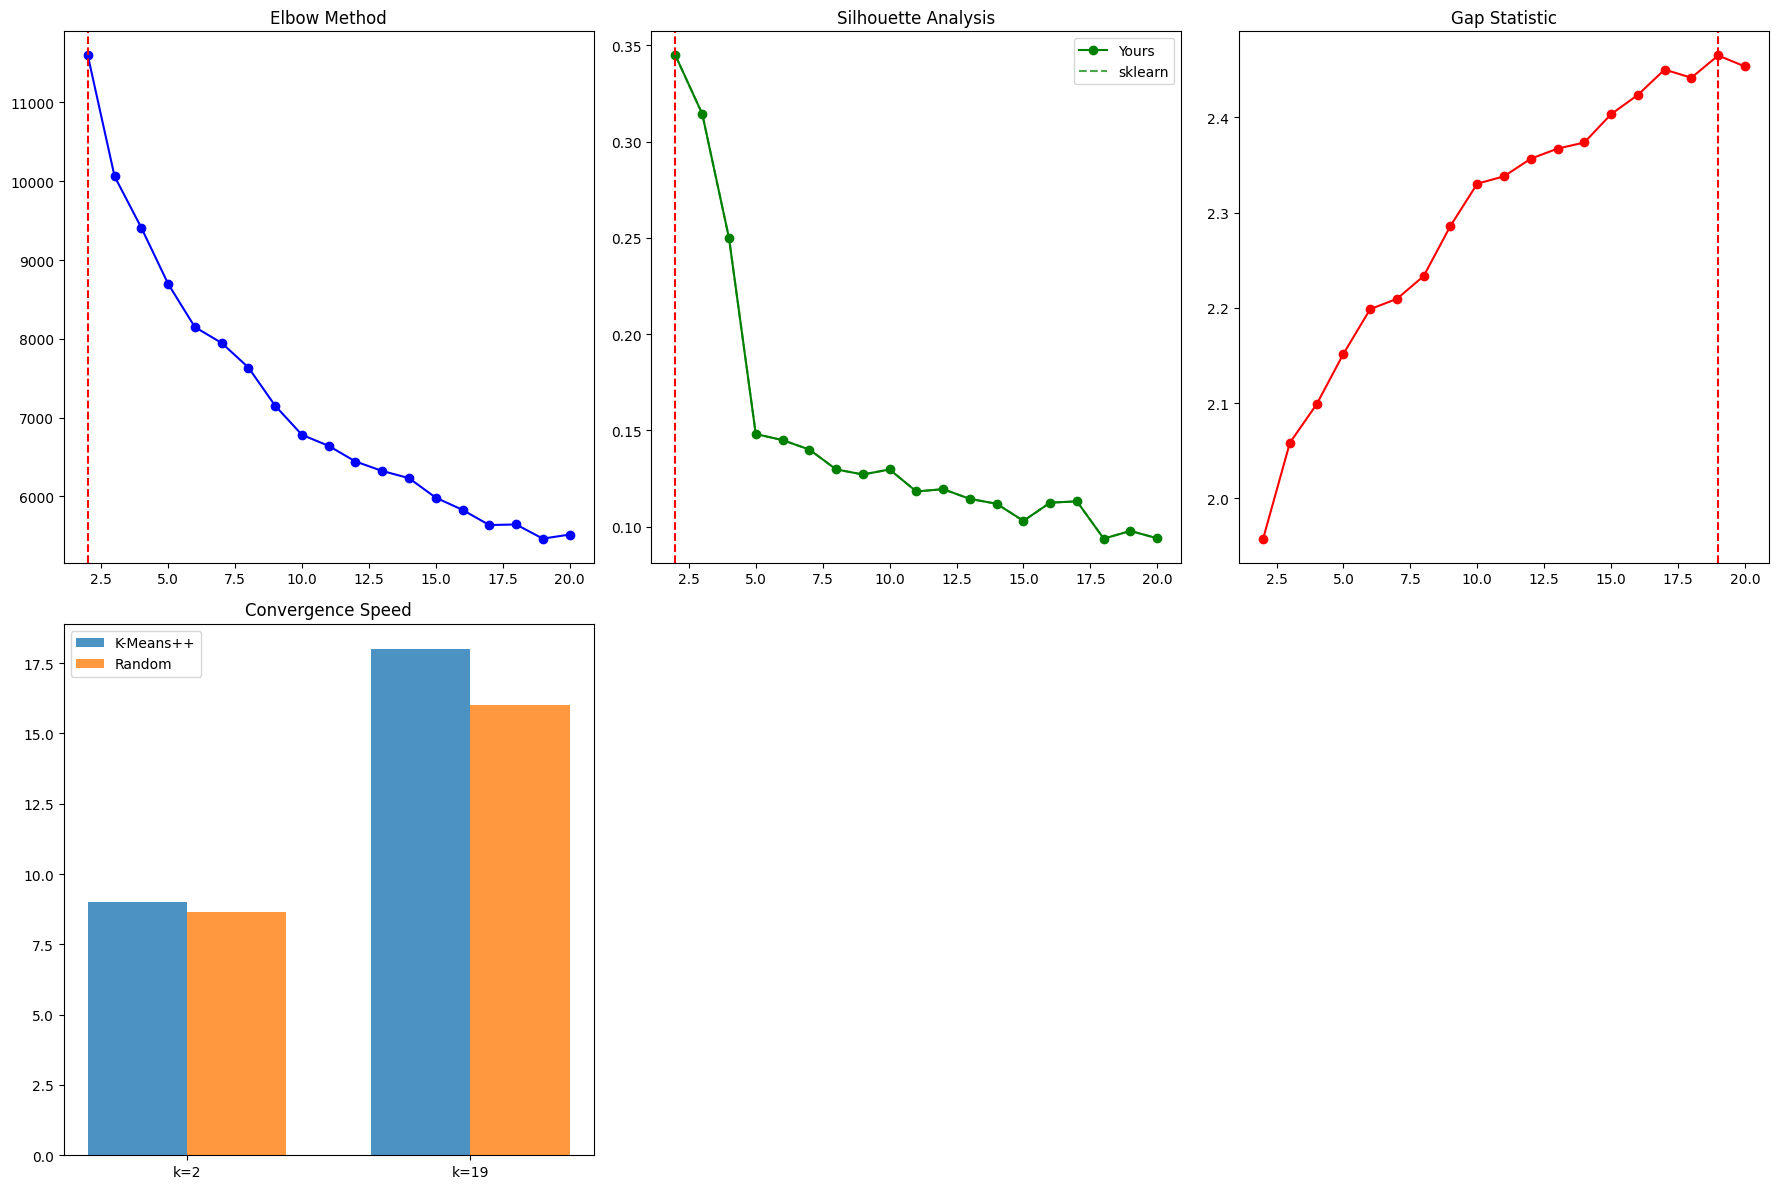


✅ EXPERIMENT 1 COMPLETE!
Optimal k: 2
K-Means++ 13.5±4.5 iterations
Random init 12.3±3.7 iterations
(K-Means++ marginally faster)


In [127]:
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# Elbow
axes[0,0].plot(k_range, inertias_pp, 'bo-')
axes[0,0].axvline(np.argmin(np.diff(inertias_pp))+2, c='r', ls='--')
axes[0,0].set_title('Elbow Method')

# Silhouette
axes[0,1].plot(k_range, sil_scores, 'go-', label='Yours')
axes[0,1].plot(k_range, sil_scores_sk, 'g--', alpha=0.7, label='sklearn')
axes[0,1].axvline(k_sil, c='r', ls='--')
axes[0,1].set_title('Silhouette Analysis')
axes[0,1].legend()

# Gap
axes[0,2].plot(k_range, gaps, 'ro-')
axes[0,2].axvline(k_gap, c='r', ls='--')
axes[0,2].set_title('Gap Statistic')

# Convergence
k_labels = [k_sil, k_gap]
x = np.arange(len(k_labels))
width = 0.35
axes[1,0].bar(x - width/2, conv_pp, width, label='K-Means++', alpha=0.8)
axes[1,0].bar(x + width/2, conv_rand, width, label='Random', alpha=0.8)
axes[1,0].set_title('Convergence Speed')
axes[1,0].set_xticks(x)
axes[1,0].set_xticklabels([f'k={k}' for k in k_labels])
axes[1,0].legend()

plt.tight_layout()
axes[1,1].axis('off')
axes[1,2].axis('off')
plt.savefig('experiment1_results.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✅ EXPERIMENT 1 COMPLETE!")
print(f"Optimal k: {optimal_k}")
print(f"K-Means++ {np.mean(conv_pp):.1f}±{np.std(conv_pp):.1f} iterations")
print(f"Random init {np.mean(conv_rand):.1f}±{np.std(conv_rand):.1f} iterations")
print("(K-Means++ marginally faster)")